<a href="https://colab.research.google.com/github/rashmib21/Data-Analysis-of-Stock-Market-from-2016-to-2026/blob/main/open_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Install pmdarima if not already installed and import auto_arima
try:
    from pmdarima import auto_arima
except ImportError:
    !pip install pmdarima
    # After installation, try importing again to make it available
    from pmdarima import auto_arima

# Install odfpy for reading .ods files if not already installed
try:
    import odfpy
except ImportError:
    !pip install odfpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

### Load and Preprocess Data

I will load the `Hindustan_copper.ods` file, parse the 'Date' column as datetime, set it as the index, sort it, and assign a business day frequency. Then, I will extract the 'Open' column as the target series for our time series analysis.

In [3]:
# Load the .ods file
df = pd.read_excel('/content/Hindustan_copper.ods', engine='odf')

# Assuming the datetime column is named 'datetime' and the target column is 'open'
# Parse datetime column, set as index, and sort
df['Date'] = pd.to_datetime(df['datetime'])
df = df.set_index('Date').sort_index()

# Assign business day frequency, filling forward for missing days
df = df.asfreq('B', method='ffill')

# Extract the 'open' column as the target series
series = df['open']

print("Original Series Head:")
display(series.head())
print("Original Series Tail:")
display(series.tail())
print(f"Series shape: {series.shape}")

Original Series Head:


,open
Date,
2016-01-04 00:00:00+05:30,84.20
2016-01-05 00:00:00+05:30,82.00
2016-01-06 00:00:00+05:30,82.40
2016-01-07 00:00:00+05:30,79.00
2016-01-08 00:00:00+05:30,77.45


Original Series Tail:


,open
Date,
2026-03-24 00:00:00+05:30,849.0
2026-03-25 00:00:00+05:30,866.0
2026-03-26 00:00:00+05:30,866.0
2026-03-27 00:00:00+05:30,860.0
2026-03-30 00:00:00+05:30,876.0


Series shape: (2671,)


### Split Data into Train and Test Sets

I will split the data into 80% for training and 20% for testing, ensuring that the time order is maintained.

In [4]:
# Split data into train and test sets (80% train, 20% test)
train_size = int(len(series) * 0.8)
train, test = series[0:train_size], series[train_size:len(series)]

print(f"Train set size: {len(train)}")
print(f"Test set size: {len(test)}")

Train set size: 2136
Test set size: 535


### Find Optimal ARIMA Order and Perform Walk-Forward Validation

I will use `pmdarima.auto_arima` to find the best (p,d,q) order for the ARIMA model. Then, I will perform walk-forward validation, retraining the model on historical data and predicting one step ahead for each point in the test set.

In [5]:
# Find the best ARIMA order using auto_arima
model_auto_arima = auto_arima(train, seasonal=False, stepwise=True, suppress_warnings=True, error_action='ignore')
final_arima_order = model_auto_arima.order
print(f"Best ARIMA Order: {final_arima_order}")

# Walk-forward validation
history = list(train)
predictions = []

for t in range(len(test)):
    # Retrain the model on the updated history using innovations_mle for speed
    model = ARIMA(history, order=final_arima_order)
    model_fit = model.fit(method='innovations_mle', low_memory=True)

    # Predict one step ahead
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)

    # Append actual observation to history for the next iteration
    obs = test.iloc[t]
    history.append(obs)

    # Progress update every 50 steps
    if t % 50 == 0:
        print(f'Step {t+1}/{len(test)} — predicted={yhat:.3f}, expected={obs:.3f}')

# Convert predictions to a pandas Series with the test index
predictions_series = pd.Series(predictions, index=test.index)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test, predictions_series))
print(f'RMSE: {rmse:.3f}')

Best ARIMA Order: (2, 1, 2)
Step 1/535 — predicted=539.108, expected=533.100
Step 51/535 — predicted=661.979, expected=666.300
Step 101/535 — predicted=675.682, expected=665.000
Step 151/535 — predicted=752.983, expected=723.500
Step 201/535 — predicted=659.523, expected=649.500
Step 251/535 — predicted=643.329, expected=636.000
Step 301/535 — predicted=634.230, expected=638.950
Step 351/535 — predicted=670.140, expected=670.000
Step 401/535 — predicted=743.014, expected=745.000
Step 451/535 — predicted=819.270, expected=811.000
Step 501/535 — predicted=960.583, expected=970.250
RMSE: 14.512


### Display Expected vs. Predicted Values

Here are the actual 'Open' prices from the test set compared to the ARIMA model's predictions.

In [6]:
results_df = pd.DataFrame({'Expected': test, 'Predicted': predictions_series})
display(results_df.head())
display(results_df.tail())

,Expected,Predicted
Date,,
2024-03-12 00:00:00+05:30,533.10,539.107524
2024-03-13 00:00:00+05:30,529.35,532.525768
2024-03-14 00:00:00+05:30,512.00,530.189427
2024-03-15 00:00:00+05:30,522.00,512.111614
2024-03-18 00:00:00+05:30,532.00,520.994214


,Expected,Predicted
Date,,
2026-03-24 00:00:00+05:30,849.0,857.377629
2026-03-25 00:00:00+05:30,866.0,848.276985
2026-03-26 00:00:00+05:30,866.0,862.316969
2026-03-27 00:00:00+05:30,860.0,864.078132
2026-03-30 00:00:00+05:30,876.0,859.185914


### Visualize Results

Below are two plots: a full view comparing the train, test, and predicted values, and a zoomed-in view focusing on the test period to better assess the model's performance.

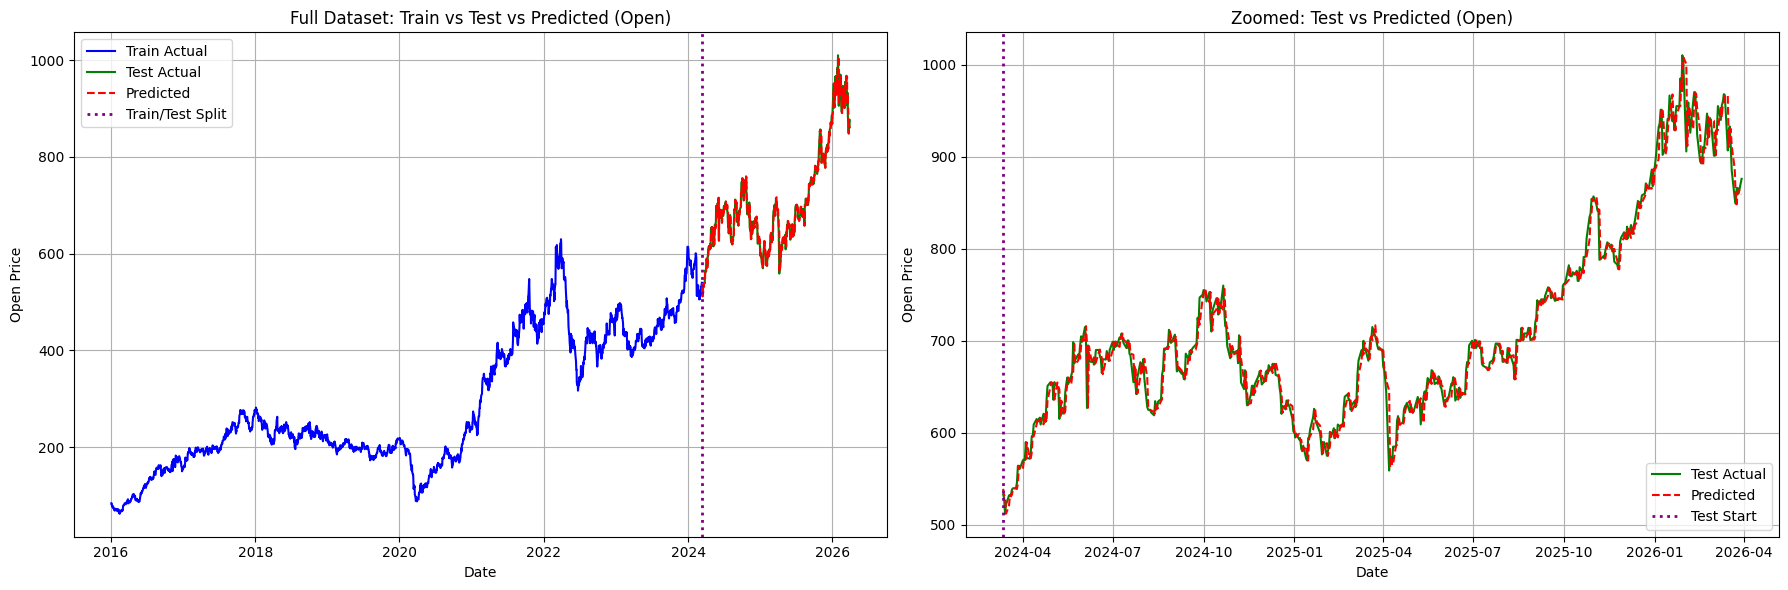

In [7]:
plt.figure(figsize=(18, 6))

# Left Subplot: Full Dataset View
plt.subplot(1, 2, 1)
plt.plot(train.index, train, color='blue', label='Train Actual')
plt.plot(test.index, test, color='green', label='Test Actual')
plt.plot(predictions_series.index, predictions_series, color='red', linestyle='--', label='Predicted')
plt.axvline(x=train.index[-1], color='purple', linestyle=':', linewidth=2, label='Train/Test Split')
plt.title('Full Dataset: Train vs Test vs Predicted (Open)')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.legend()
plt.grid(True)

# Right Subplot: Zoomed Test-Only View
plt.subplot(1, 2, 2)
plt.plot(test.index, test, color='green', label='Test Actual')
plt.plot(predictions_series.index, predictions_series, color='red', linestyle='--', label='Predicted')
plt.axvline(x=test.index[0], color='purple', linestyle=':', linewidth=2, label='Test Start')
plt.title('Zoomed: Test vs Predicted (Open)')
plt.xlabel('Date')
plt.ylabel('Open Price')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Summary of Results

Finally, here are the optimal ARIMA order found and the Root Mean Squared Error (RMSE) for the predictions.

In [8]:
print(f"Final ARIMA Order: {final_arima_order}")
print(f"Final RMSE: {rmse:.3f}")

Final ARIMA Order: (2, 1, 2)
Final RMSE: 14.512
